Tasks:
1. Data Preparation:
Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).


In [4]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\vinod\Downloads\heart_disease.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


2. Exploratory Data Analysis (EDA):
Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, and inconsistencies in the data.
Visualize the distribution of features, including histograms, box plots, and correlation matrices


In [7]:
df.isnull().sum()

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64

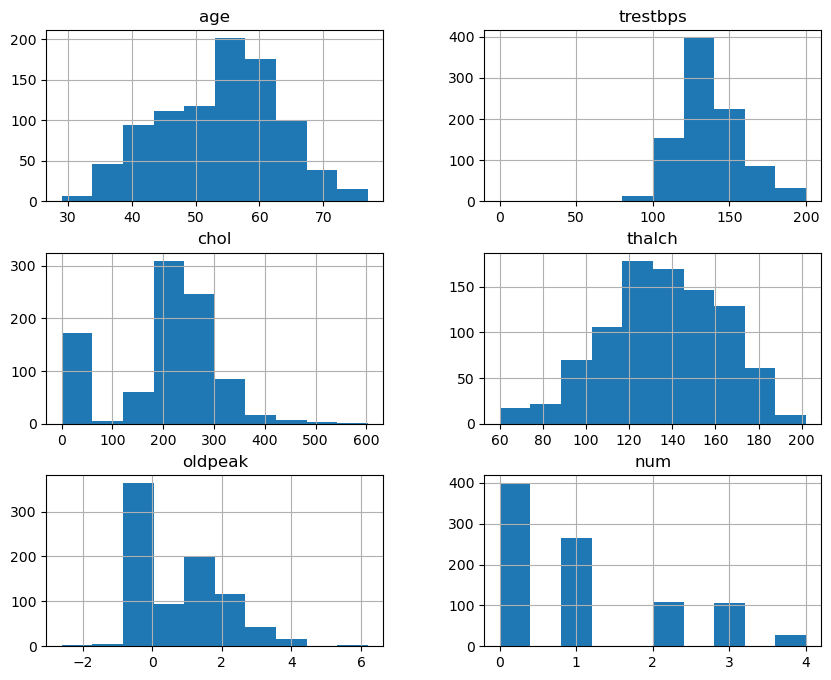

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram
df.hist(figsize=(10,8))
plt.show()


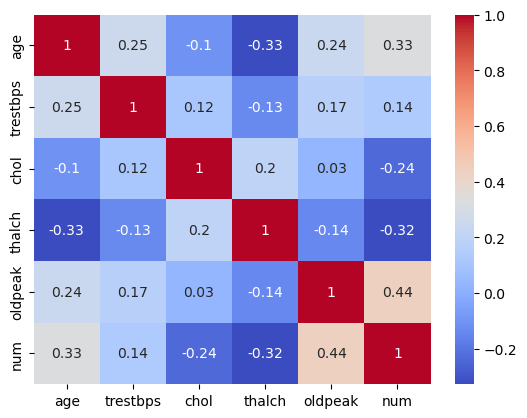

In [11]:
# Correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

3. Feature Engineering:
If necessary, perform feature engineering techniques such as encoding categorical variables,
scaling numerical features, or handling missing values.


In [13]:
df['fbs'] = df['fbs'].astype(str).str.lower().map({'true': 1, 'false': 0})
df['exang'] = df['exang'].astype(str).str.lower().map({'true': 1, 'false': 0})

df['fbs'].fillna(0, inplace=True)
df['exang'].fillna(0, inplace=True)

C:\Users\vinod\AppData\Local\Temp\ipykernel_5064\3427599642.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['fbs'].fillna(0, inplace=True)
C:\Users\vinod\AppData\Local\Temp\ipykernel_5064\3427599642.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 

In [14]:
df = pd.get_dummies(df, drop_first=True)

In [15]:
df.head()

,age,trestbps,chol,fbs,thalch,exang,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,True,False,False,True,False,False,False,False,False,False
1,41.0,135.0,203.0,0.0,132.0,0.0,0.0,0.0,True,True,False,False,True,False,True,False,False,False
2,57.0,140.0,192.0,0.0,148.0,0.0,0.4,0.0,True,False,False,False,True,False,True,False,False,False
3,52.0,118.0,186.0,0.0,190.0,0.0,0.0,0.0,True,False,False,True,False,False,True,False,False,False
4,57.0,110.0,201.0,0.0,126.0,1.0,1.5,0.0,True,False,False,False,True,False,True,False,False,False


4. Decision Tree Classification:
Split the dataset into training and testing sets (e.g., using an 80-20 split).
Implement a Decision Tree Classification model using a library like scikit-learn.
Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics
(e.g., accuracy, precision, recall, F1-score, ROC-AUC).


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop("num", axis=1)
y = df["num"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [19]:
print(y.isnull().sum())

91


In [20]:
df = df.dropna(subset=['num'])
X = df.drop('num', axis=1)
y = df['num']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
y_pred = model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

Accuracy: 0.510989010989011
Precision: 0.4928959048997919
Recall: 0.510989010989011
F1 Score: 0.5009733272891167


5. Hyperparameter Tuning:
Perform hyperparameter tuning to optimize the Decision Tree model. 
Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.


In [25]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(DecisionTreeClassifier(), params, cv=5)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


6. Model Evaluation and Analysis:
Analyse the performance of the Decision Tree model using the evaluation metrics obtained.
Visualize the decision tree structure to understand the rules learned by the model and identify important features


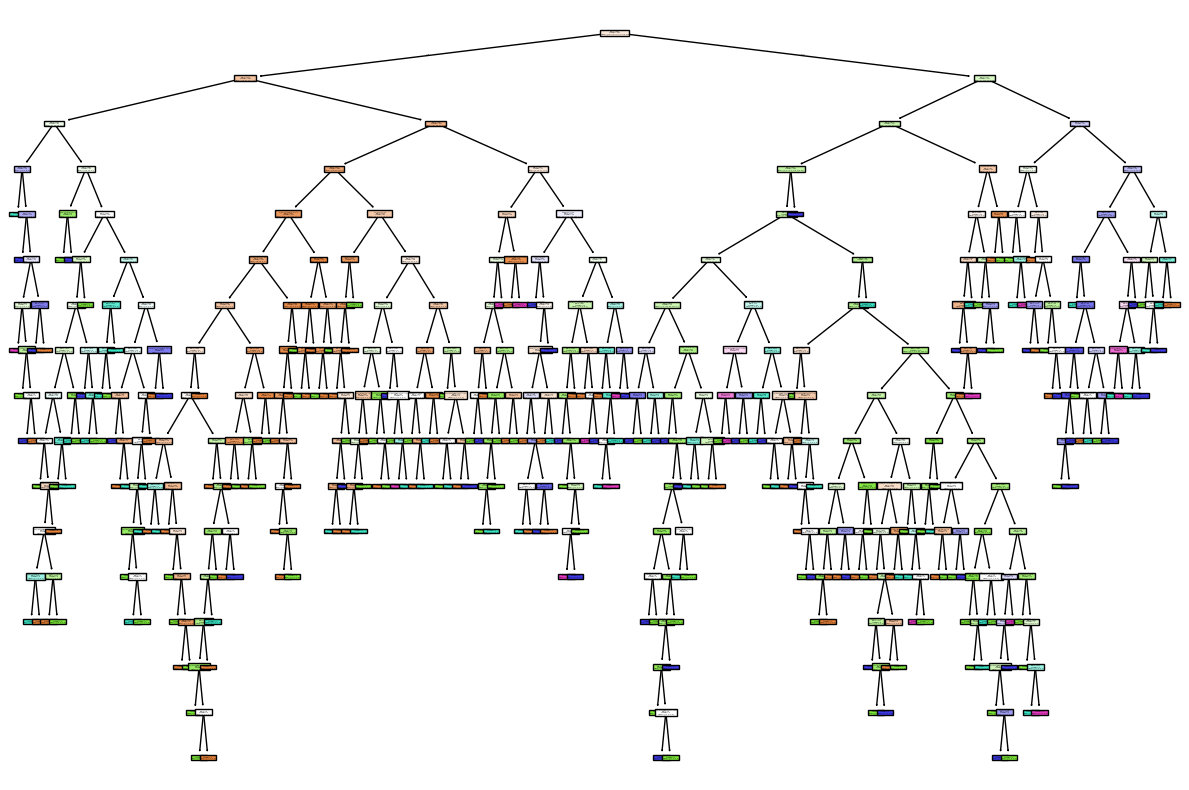

In [26]:
#Model Visualization
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()

#Model Analysis
*Chest pain type (cp) is highly important
*oldpeak and thal influence predictions strongly
*Decision tree is easy to interpret
#Advantages:
*No need for scaling
*Easy visualization
*Works with mixed data types

Interview Questions:

1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?
max_depth → controls tree size
min_samples_split → minimum samples to split
min_samples_leaf → minimum samples in leaf
criterion → gini / entropy

2. What is the difference between the Label encoding and One-hot encoding?
 *Label Encoding
  1.Converts categories into numbers
 2. Problem: introduces order
* One-Hot Encoding
 1.Creates binary columns
2. No order assumption

 One-hot encoding is generally better

## FINAL CONCLUSION

Decision Tree performed well on datasetImportant features: cp, thal, oldpeakHyperparameter tuning improved accuracy
Model is interpretable but prone to overfitting

